In [56]:
import pandas as pd
import numpy as np

review = pd.read_csv("../outputs/dp001_review_clean.csv")
prac = pd.read_csv("../outputs/dp001_prac_clean.csv")

In [57]:
review["start_time"] = pd.to_datetime(review["start_time"])
review["end_time"] = pd.to_datetime(review["end_time"])
prac["date"] = pd.to_datetime(prac["date"])

### 影片學習投入指標

In [58]:
review["watch_time"] = review["end_timestamp"] - review["start_timestamp"]

review = review[
    (review["watch_time"] >= 0) &
    (review["watch_time"] <= review["video_len"])
]

In [59]:
video_feat = review.groupby("user_sn").agg(
    video_count=("review_sn", "nunique"),
    total_watch_time=("watch_time", "sum"),
    avg_finish_rate=("finish_rate", "mean"),
    full_watch_ratio=("finish_rate", lambda x: (x >= 90).mean())
).reset_index()

video_feat.describe()

,user_sn,video_count,total_watch_time,avg_finish_rate,full_watch_ratio
count,686.000000,686.000000,686.000000,686.000000,686.000000
mean,107236.209913,18.529155,4397.500073,69.653663,0.571646
std,62183.989835,22.268531,6251.084793,24.635822,0.316676
min,50.000000,1.000000,0.000000,0.000000,0.000000
25%,51740.000000,3.000000,614.225000,56.266447,0.375000
50%,110663.500000,10.000000,2312.600000,73.971748,0.593750
75%,160235.250000,25.000000,5007.465000,89.034191,0.838333
max,215279.000000,173.000000,66579.840000,100.000000,1.000000


### 練習作答投入指標

In [60]:
prac["score_rate"].value_counts(dropna=False).head(10)

score_rate
1.00    13777
0.50     5840
0.00     4547
0.67      255
0.33      213
0.87       61
0.93       57
0.80       50
0.75       49
0.25       48
Name: count, dtype: int64

In [61]:
prac["item_count"] = prac["binary_res"].apply(
    lambda x: len(str(x).split("@XX@"))
)

In [62]:
prac_feat = prac.groupby("user_sn").agg(
    prac_count=("prac_sn", "nunique"),
    avg_score_rate=("score_rate", "mean"),  # 自動忽略 NaN
    total_items=("item_count", "sum")
).reset_index()

prac_feat.describe()

,user_sn,prac_count,avg_score_rate,total_items
count,935.000000,935.000000,935.000000,935.000000
mean,106633.823529,26.639572,0.726605,85.759358
std,61589.816773,37.568062,0.178222,115.856197
min,50.000000,1.000000,0.000000,3.000000
25%,51189.000000,5.000000,0.625000,22.000000
50%,110710.000000,12.000000,0.740741,47.000000
75%,158397.000000,32.000000,0.857208,98.500000
max,215409.000000,436.000000,1.000000,1332.000000


### 整合「學習投入特徵表」

In [63]:
engagement = video_feat.merge(
    prac_feat,
    on="user_sn",
    how="left"
)

engagement["prac_count"] = engagement["prac_count"].fillna(0)
engagement["total_items"] = engagement["total_items"].fillna(0)

In [64]:
engagement.info()
engagement.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_sn           686 non-null    int64  
 1   video_count       686 non-null    int64  
 2   total_watch_time  686 non-null    float64
 3   avg_finish_rate   686 non-null    float64
 4   full_watch_ratio  686 non-null    float64
 5   prac_count        686 non-null    float64
 6   avg_score_rate    680 non-null    float64
 7   total_items       686 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 43.0 KB


,user_sn,video_count,total_watch_time,avg_finish_rate,full_watch_ratio,prac_count,avg_score_rate,total_items
0,50,27,2520.56,83.222222,0.777778,27.0,0.487778,84.0
1,249,96,23801.04,67.270833,0.593750,134.0,0.524058,460.0
2,386,9,2312.60,60.555556,0.444444,18.0,0.770000,93.0
3,444,6,2535.34,50.333333,0.333333,10.0,0.547000,45.0
4,562,21,5860.95,65.571429,0.523810,30.0,0.700000,90.0


In [65]:
engagement.to_csv("../outputs/engagement_features.csv", index=False)

### 建立學習投入指數

In [66]:
from sklearn.preprocessing import StandardScaler

eng_cols = [
    "prac_count",
    "total_items",
    "avg_score_rate",
    "video_count",
    "total_watch_time",
    "avg_finish_rate",
    "full_watch_ratio"
]

scaler = StandardScaler()
prac_feat_std = engagement.copy()
prac_feat_std[eng_cols] = scaler.fit_transform(engagement[eng_cols])

prac_feat_std["engagement_index"] = prac_feat_std[eng_cols].mean(axis=1)

prac_feat_std[["user_sn", "engagement_index"]].head()

,user_sn,engagement_index
0,50,-0.057664
1,249,1.518649
2,386,-0.236948
3,444,-0.634848
4,562,-0.036273


### 建立「整體學習投入指數」

In [67]:
# prac_feat_std["engagement_index"] = (
#     prac_feat_std["prac_count"] +
#     prac_feat_std["total_items"] +
#     prac_feat_std["avg_score_rate"] +
#     prac_feat_std["video_count"] +
#     prac_feat_std["total_watch_time"] +
#     prac_feat_std["avg_finish_rate"] +
#     prac_feat_std["full_watch_ratio"]
# ) / 3

prac_feat_std["engagement_index"] = prac_feat_std[eng_cols].mean(axis=1)

### 建立高 / 低投入組

In [68]:
median_eng = prac_feat_std["engagement_index"].median()

prac_feat_std["eng_group"] = np.where(
    prac_feat_std["engagement_index"] >= median_eng,
    "High",
    "Low"
)

prac_feat_std["eng_group"].value_counts()

eng_group
Low     343
High    343
Name: count, dtype: int64

### 合併學習成效

In [69]:
user = pd.read_csv("../data/user_data.csv")

data_final = prac_feat_std.merge(
    user[["user_sn", "chinese_score", "math_score", "english_score"]],
    on="user_sn",
    how="left"
)

print(data_final.head())

   user_sn  video_count  total_watch_time  avg_finish_rate  full_watch_ratio  \
0       50     0.380673         -0.300477         0.551167          0.651399   
1      249     3.481477          3.106293        -0.096793          0.069852   
2      386    -0.428232         -0.333769        -0.369573         -0.401970   
3      444    -0.563050         -0.298111        -0.784809         -0.753093   
4      562     0.111038          0.234282        -0.165824         -0.151168   

   prac_count  avg_score_rate  total_items  engagement_index eng_group  \
0   -0.154598       -1.353164    -0.178647         -0.057664       Low   
1    2.432083       -1.133561     2.771190          1.518649      High   
2   -0.372169        0.355116    -0.108039         -0.236948       Low   
3   -0.565566       -0.994694    -0.484614         -0.634848       Low   
4   -0.082074       -0.068591    -0.131575         -0.036273       Low   

   chinese_score  math_score  english_score  
0           96.0        88.0

### 高 / 低學習投入組之學習成效差異分析

### 描述統計

In [70]:
group_desc = data_final.groupby("eng_group")[
    ["chinese_score", "math_score", "english_score"]
].agg(["count", "mean", "std"])

group_desc

chinese_score                       math_score             \
                  count       mean        std      count       mean   
eng_group                                                             
High                340  89.164706  11.549403        343  78.775510   
Low                 330  81.454545  16.411670        336  69.380952   

                     english_score                        
                 std         count       mean        std  
eng_group                                                 
High       17.237057           341  86.589443  15.406313  
Low        20.529065           323  77.331269  20.246275

### 獨立樣本 t-test

In [71]:
data_t = data_final[[
    "user_sn",
    "eng_group",
    "chinese_score",
    "math_score",
    "english_score"
]].dropna()

In [72]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

rows = []

for subject in ["chinese_score", "math_score", "english_score"]:
    
    high = data_t.loc[data_t["eng_group"] == "High", subject]
    low  = data_t.loc[data_t["eng_group"] == "Low",  subject]
    
    t, p = ttest_ind(high, low, equal_var=False)   # Welch t-test（比較穩定）
    
    # Cohen’s d
    pooled_sd = np.sqrt(((high.var(ddof=1) + low.var(ddof=1)) / 2))
    d = (high.mean() - low.mean()) / pooled_sd
    
    rows.append({
        "subject": subject,
        "High_mean": high.mean(),
        "Low_mean": low.mean(),
        "t": t,
        "p": p,
        "sig": "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns",
        "cohens_d": d
    })

tt_table = pd.DataFrame(rows)
tt_table


,subject,High_mean,Low_mean,t,p,sig,cohens_d
0,chinese_score,89.164706,81.602564,6.688541,5.565960e-11,***,0.528286
1,math_score,78.964706,70.833333,5.479186,6.255419e-08,***,0.431125
2,english_score,86.655882,77.330128,6.545809,1.309923e-10,***,0.516205


### *cohens_d解讀標準: 0.2 = 小, 0.5 = 中, 0.8 = 大

### 學習投入指標與學習成效之相關分析

### Pearson 相關分析

In [73]:
from scipy.stats import pearsonr

def run_pearson(df, x, y):
    tmp = df[[x, y]].dropna()
    r, p = pearsonr(tmp[x], tmp[y])
    return r, p, len(tmp)

In [74]:
pearson_results = []

for subject in ["chinese_score", "math_score", "english_score"]:
    r, p, n = run_pearson(data_final, "engagement_index", subject)
    pearson_results.append({
        "subject": subject,
        "r": r,
        "p": p,
        "n": n
    })

pearson_df = pd.DataFrame(pearson_results)
pearson_df

,subject,r,p,n
0,chinese_score,0.243424,1.709427e-10,670
1,math_score,0.169823,8.611757e-06,679
2,english_score,0.226082,3.834266e-09,664


### 加上顯著性標記

In [75]:
def sig_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

pearson_df["sig"] = pearson_df["p"].apply(sig_star)
pearson_df

,subject,r,p,n,sig
0,chinese_score,0.243424,1.709427e-10,670,***
1,math_score,0.169823,8.611757e-06,679,***
2,english_score,0.226082,3.834266e-09,664,***


### *相關係數r(絕對值)的解讀: 0.10–0.29 -> 弱相關, 0.30–0.49 -> 中度相關, >= 0.50 -> 高相關

### 畫圖

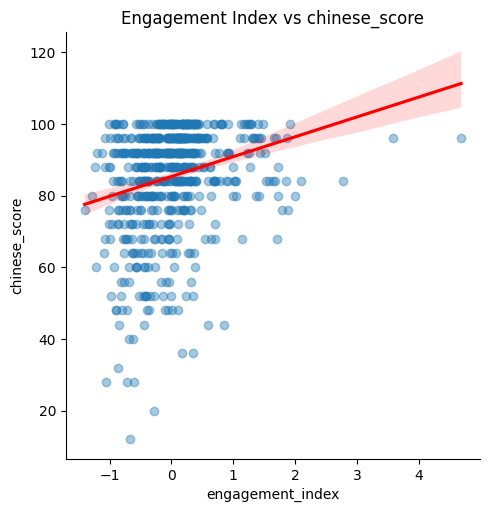

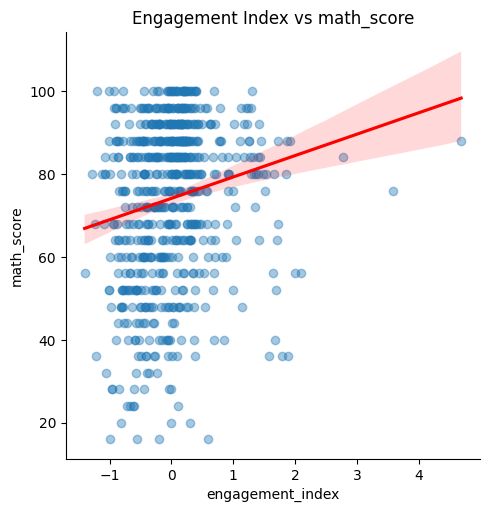

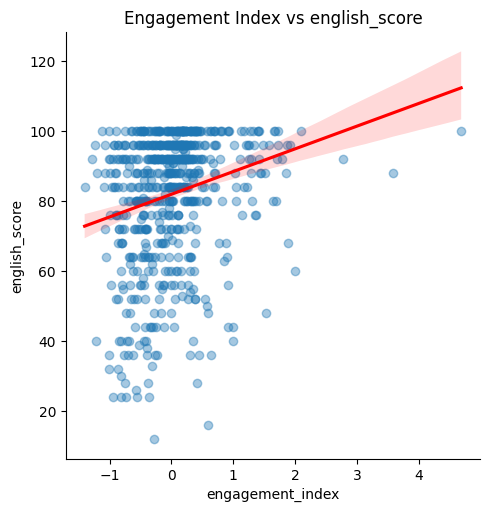

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

for subject in ["chinese_score", "math_score", "english_score"]:
    sns.lmplot(
        data=data_final,
        x="engagement_index",
        y=subject,
        scatter_kws={"alpha": 0.4},
        line_kws={"color": "red"}
    )
    plt.title(f"Engagement Index vs {subject}")
    plt.show()

### Spearman 檢查

In [77]:
from scipy.stats import spearmanr

spearman_results = []

for subject in ["chinese_score", "math_score", "english_score"]:
    tmp = data_final[["engagement_index", subject]].dropna()
    rho, p = spearmanr(tmp["engagement_index"], tmp[subject])
    spearman_results.append({
        "subject": subject,
        "rho": rho,
        "p": p
    })

pd.DataFrame(spearman_results)

,subject,rho,p
0,chinese_score,0.282371,9.518043e-14
1,math_score,0.214277,1.711446e-08
2,english_score,0.267475,2.427090e-12
